**Course outline:** Unit 03 · Notebook 01 · Python

# Data or information?

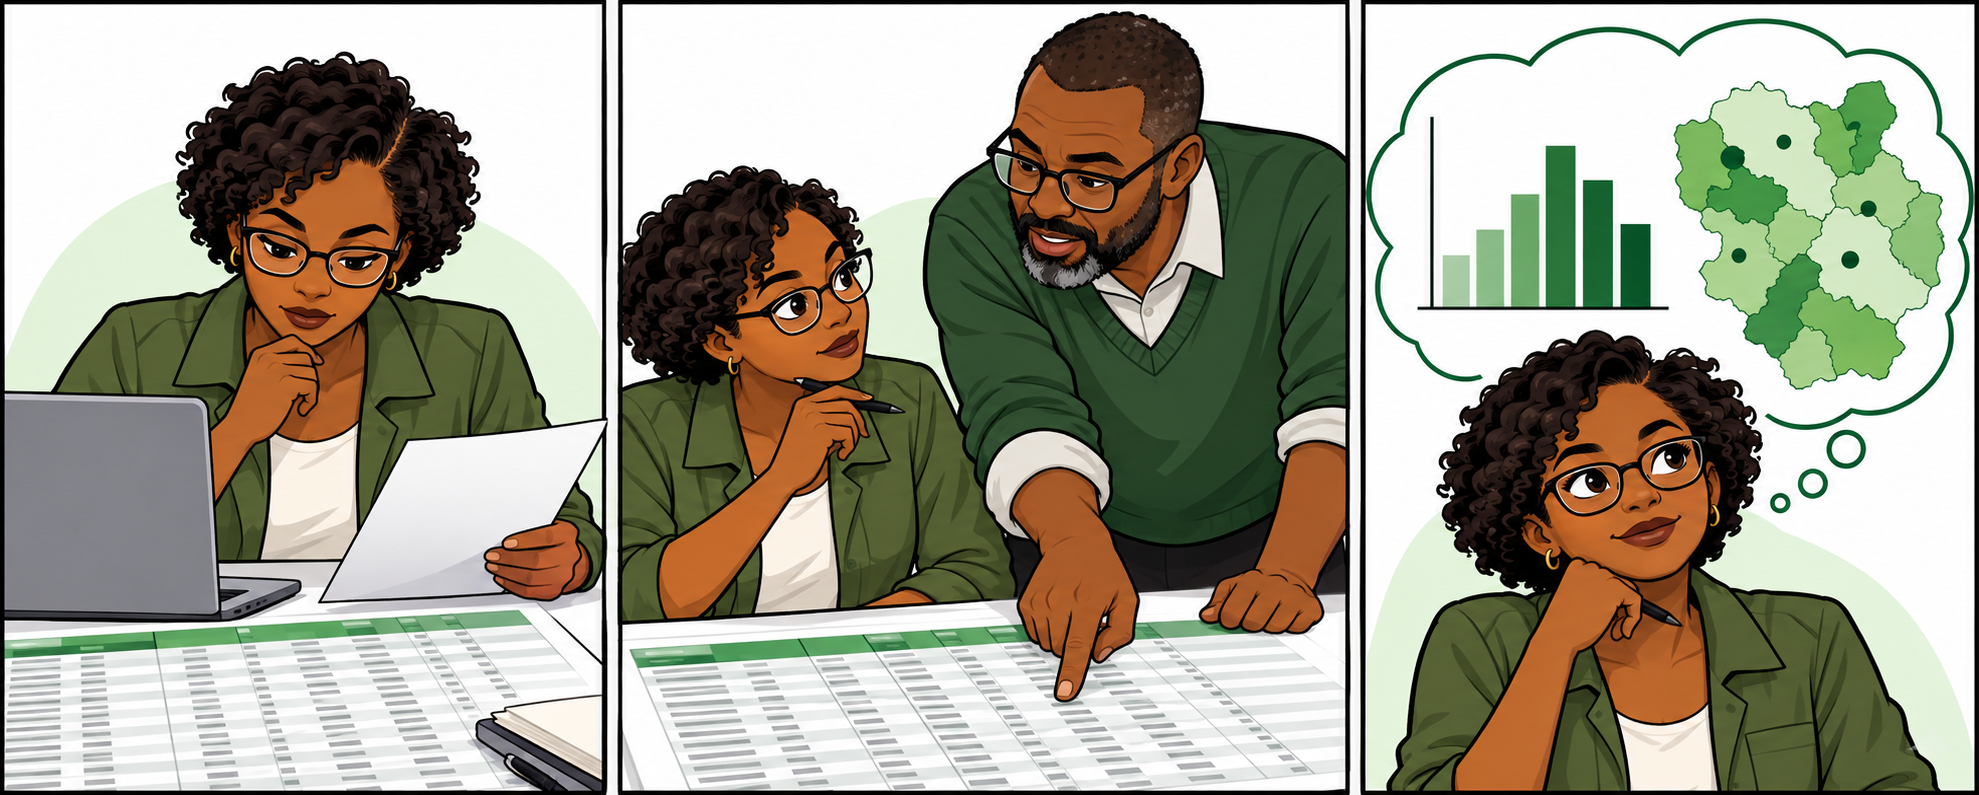

*Laila has ages, symptoms, and onset dates. Her supervisor asks which items already show a pattern. Help Laila tell raw data from information. (Original teaching illustration; dialogue is not from the slides.)*

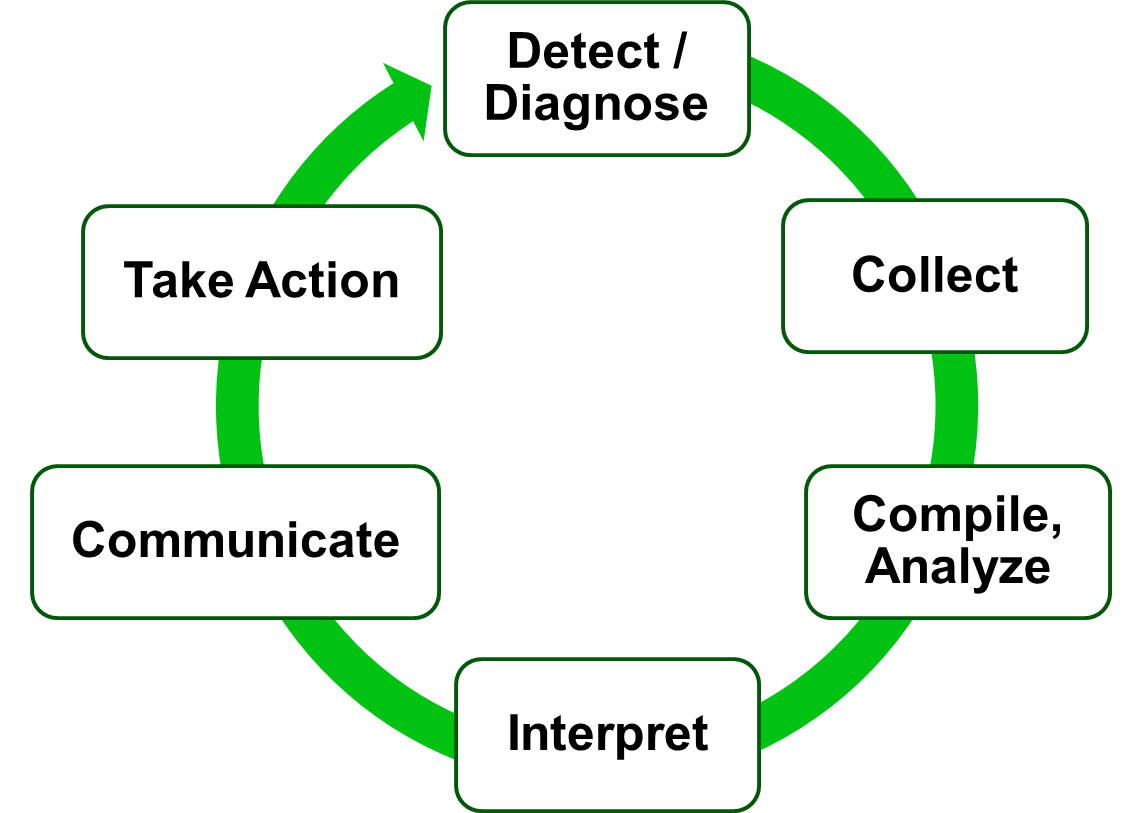

*Slide connection: Unit 2, Version 2, slide 3. This notebook works at the **data → information** step, where collected values become a pattern that can be interpreted.*

*Unit 3: Using Informatics to Get Information Faster*. Learning objective: **Classify example items as raw data or information**.

**Data** are raw, unorganized numbers and facts: single variables that have limited value in isolation. **Information** is organized and structured data: it combines multiple variables to uncover patterns, trends, and relationships. (Data – Information – Knowledge – Wisdom pyramid.)

## Your task

Run the collapsed setup cell once to display the sorting board. Drag each of the six slide examples from **To sort** into **Data** or **Information**. You can also use each card's **Move to** menu. Then run **Check my choices**; you do not need to type an answer. Move a card and run that cell again to retry.

Run the collapsed setup cell, sort all six cards, then run **Check my choices**. The **Learning** panel records each attempt and suggests what to do next. Hints are available there; using more than two lowers how much this attempt counts as evidence.

In [ ]:
# Run once to display the sorting board. Re-running resets the choices.
try:
    import anywidget
except ImportError:
    import piplite
    await piplite.install(["ipywidgets==8.1.7", "anywidget==0.11.0"])
    import anywidget
import traitlets
from IPython.display import display

items = {'a': 'Age', 'b': 'Heat (choropleth) map', 'c': 'Clinical sign or symptom', 'd': 'Date of onset', 'e': 'Table showing number of cases by age categories', 'f': 'Epi curve showing number of cases by epi week'}
class DataBins(anywidget.AnyWidget):
    _esm = "// Embedded in the generated U03 N01 notebook by make_exercises.py.\n// No external JavaScript or network requests are needed at learner runtime.\nexport default {\n  render({ model, el, signal }) {\n    const root = el.shadowRoot || el.attachShadow({ mode: 'open' });\n    const style = document.createElement('style');\n    style.textContent = `\n      .board { font: 14px/1.4 system-ui, sans-serif; color: #202936; }\n      .hint { margin: 0 0 12px; }\n      .zones { display: grid; grid-template-columns: repeat(3, minmax(0, 1fr)); gap: 12px; }\n      .zone { min-height: 160px; padding: 10px; border: 2px dashed #8190a1;\n              border-radius: 8px; background: #f7f9fb; }\n      .zone.over { border-color: #176b8a; background: #e9f5fa; }\n      .zone h3 { margin: 0 0 9px; font-size: 16px; }\n      .card { margin: 0 0 8px; padding: 9px; border: 1px solid #a7b5c4;\n              border-radius: 6px; background: white; cursor: grab; }\n      .card:active { cursor: grabbing; }\n      .card p { margin: 0 0 7px; }\n      .card label { display: block; font-size: 12px; }\n      .card select { width: 100%; margin-top: 3px; padding: 4px; font: inherit; }\n      .count { margin-top: 10px; font-size: 12px; }\n      @media (max-width: 720px) { .zones { grid-template-columns: 1fr; } }\n    `;\n    const board = document.createElement('div');\n    board.className = 'board';\n    root.replaceChildren(style, board);\n\n    const items = Object.entries(model.get('items'));\n    const move = (key, bin) => {\n      const assignments = { ...model.get('assignments') };\n      if (bin === 'unsorted') delete assignments[key];\n      else assignments[key] = bin;\n      model.set('assignments', assignments);\n      model.save_changes();\n      draw();\n    };\n    const draw = () => {\n      board.replaceChildren();\n      const hint = document.createElement('p');\n      hint.className = 'hint';\n      hint.textContent = 'Drag each card into Data or Information. You can also use its Move to menu.';\n      board.appendChild(hint);\n      const zones = document.createElement('div');\n      zones.className = 'zones';\n      board.appendChild(zones);\n      const assignments = model.get('assignments');\n      for (const [bin, title] of [['unsorted', 'To sort'], ['data', 'Data'], ['information', 'Information']]) {\n        const zone = document.createElement('section');\n        zone.className = 'zone';\n        zone.dataset.zone = bin;\n        zone.setAttribute('aria-label', title + ' bin');\n        zone.addEventListener('dragover', event => {\n          event.preventDefault();\n          zone.classList.add('over');\n        });\n        zone.addEventListener('dragleave', () => zone.classList.remove('over'));\n        zone.addEventListener('drop', event => {\n          event.preventDefault();\n          zone.classList.remove('over');\n          const key = event.dataTransfer.getData('text/plain');\n          if (Object.hasOwn(model.get('items'), key)) move(key, bin);\n        });\n        const heading = document.createElement('h3');\n        heading.textContent = title;\n        zone.appendChild(heading);\n        for (const [key, text] of items) {\n          if ((assignments[key] || 'unsorted') !== bin) continue;\n          const card = document.createElement('div');\n          card.className = 'card';\n          card.dataset.item = key;\n          card.draggable = true;\n          card.addEventListener('dragstart', event => {\n            event.dataTransfer.setData('text/plain', key);\n            event.dataTransfer.effectAllowed = 'move';\n          });\n          const prompt = document.createElement('p');\n          prompt.textContent = `${key.toUpperCase()}. ${text}`;\n          card.appendChild(prompt);\n          const label = document.createElement('label');\n          label.textContent = `Move item ${key.toUpperCase()} to`;\n          const select = document.createElement('select');\n          select.setAttribute('aria-label', `Move item ${key.toUpperCase()} to`);\n          for (const [value, name] of [['unsorted', 'To sort'], ['data', 'Data'], ['information', 'Information']]) {\n            const option = document.createElement('option');\n            option.value = value;\n            option.textContent = name;\n            select.appendChild(option);\n          }\n          select.value = bin;\n          select.addEventListener('change', () => move(key, select.value));\n          label.appendChild(select);\n          card.appendChild(label);\n          zone.appendChild(card);\n        }\n        zones.appendChild(zone);\n      }\n      const count = document.createElement('div');\n      count.className = 'count';\n      count.setAttribute('role', 'status');\n      count.textContent = `${Object.keys(assignments).length} of ${items.length} items sorted`;\n      board.appendChild(count);\n    };\n    model.on('change:assignments', draw);\n    signal?.addEventListener('abort', () => model.off('change:assignments', draw));\n    draw();\n    // Running a collapsed JupyterLab cell can expand its source. Keep the\n    // infrastructure input hidden once the learner-facing output is ready.\n    const codeCell = el.closest('.jp-CodeCell');\n    const input = codeCell?.querySelector('.jp-InputArea');\n    if (input) {\n      setTimeout(() => {\n        if (codeCell.isConnected) input.style.setProperty('display', 'none', 'important');\n      }, 0);\n    }\n  }\n};\n"
    items = traitlets.Dict(default_value={}).tag(sync=True)
    assignments = traitlets.Dict(default_value={}).tag(sync=True)

data_bins = DataBins(items=items)
def collect_choices():
    selected = data_bins.assignments
    if set(selected) != set(items) or any(value not in {"data", "information"} for value in selected.values()):
        return None
    return [letter for letter, answer in selected.items() if answer == "information"]
display(data_bins)


In [ ]:
# Check my choices: run this cell after selecting all six answers.
information_items = collect_choices()


## References

- [Unit 3 instructor guide (Google Docs)](https://docs.google.com/document/d/1B6qrW7QBcL4uCO85QPIN8pJ--37S8N6j3xkT87qBACA)
- [Unit 3 slides, v3 revised 2025-05-13 (Google Slides)](https://docs.google.com/presentation/d/1EXkFCxffubjhpM94373WiJ0a9_V0Tsfn): slides 6, 18–24
- [Unit 3 knowledge check (Google Forms)](https://forms.gle/Y4yG5gMbFznczrBd9)
- Surveillance-cycle visual: *Unit 2, Version 2, Detection and Diagnosis*, slide 3 (course deck supplied with the project).
- Excel How-To Scribes:
  - [Make a working copy of your dataset](https://scribehow.com/shared/Create_a_copy_of_the_dataset_as_a_new_file__C7nao6DfR2OgFA63HVto9Q)
  - [Sort data using a single variable](https://scribehow.com/shared/A_guide_to_sorting_data_in_MS_Excel__OdSOUuArSBSRInz4qO6ijw)
  - [Sort data using multiple variables](https://scribehow.com/shared/A_guide_to_multiple_sorting_in_MS_Excel__NieApI7sQLSM7fcqvGqpjA)
  - [Filter data](https://scribehow.com/shared/A_guide_to_filtering_data_in_MS_Excel__tz_S8tOWTiaIyII1Qu1Wng)
  - [Use the Count function](https://scribehow.com/shared/How_big_is_your_dataset_A_guide_to_counting_rows_in_Excel__U6cLWaK9RvSmt6mz3k99Lw)
  - [Use the Max-Min function](https://scribehow.com/shared/A_guide_to_estimating_maximum_and_minimum_values_in_Excel_using_MAX_and_MIN_functions__lZiWahgvQJyEbnk45t6MJw)

*Public Health Informatics for FETP, Version 3 course materials, used with permission.*